## Introduction

When I first started reading regression outputs seriously, I used to think that a p-value was just one number telling me whether something was significant or not.

But with time, I realized that statistical models can produce many different kinds of p-values. Some p-values describe the overall model. Some describe individual predictors. Some come from Wald tests, some from likelihood ratio tests, some from ANOVA, and some from multiple-testing correction.

The most important question is not simply:

> Is the p-value less than 0.05?

A better question is:

> What exact hypothesis is this p-value testing?

This tutorial explains the major types of p-values you may see in statistical modeling, with Python examples.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

### What is a p-value?

A p-value measures how compatible the observed data are with a null hypothesis.

Very loosely, it answers:

> If the null hypothesis were true, how surprising would my observed result be?

A small p-value means that the observed data would be unlikely under the null hypothesis.

But a p-value is always connected to a specific hypothesis.

Different hypothesis means different p-value.

### Simulated Data

We will create a simple dataset with age, BMI, smoking status, and a continuous outcome.

In [2]:
n = 500

age = np.random.normal(50, 10, n)
bmi = np.random.normal(27, 4, n)
smoking = np.random.binomial(1, 0.3, n)

# Continuous outcome
y = 10 + 0.25 * age + 0.8 * bmi + 3.0 * smoking + np.random.normal(0, 5, n)

df = pd.DataFrame({
    "y": y,
    "age": age,
    "bmi": bmi,
    "smoking": smoking
})

df.head()

,y,age,bmi,smoking
0,46.478946,54.967142,30.704710,0
1,50.787874,48.617357,34.637667,0
2,34.508174,56.476885,21.405730,0
3,47.851006,65.230299,29.251877,1
4,47.434630,47.658466,24.397430,0




### 1. Model-level p-value

A model-level p-value asks whether the model as a whole explains variation in the outcome.

For example:

$Y = \beta_0 + \beta_1 Age + \beta_2 BMI + \beta_3 Smoking + \epsilon$

The null hypothesis is:


$H_0: \beta_1 = \beta_2 = \beta_3 = 0$

This means none of the predictors are associated with the outcome.

In [3]:
model = smf.ols("y ~ age + bmi + smoking", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     116.5
Date:                Fri, 15 May 2026   Prob (F-statistic):           4.06e-57
Time:                        11:10:42   Log-Likelihood:                -1503.6
No. Observations:                 500   AIC:                             3015.
Df Residuals:                     496   BIC:                             3032.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.1035      1.985      5.089      0.0

In the OLS summary, look at:

- `F-statistic`
- `Prob (F-statistic)`

The `Prob (F-statistic)` is the overall model p-value.

It asks:

> Does this model explain more variation than an intercept-only model?


### 2. Predictor-level p-values

Predictor-level p-values test individual coefficients.

For example, the p-value for BMI tests:

$ H_0: \beta_{BMI} = 0 $


This asks:

> After adjusting for age and smoking, is BMI associated with the outcome?

In [4]:
model.pvalues


Intercept    5.119553e-07
age          1.023101e-22
bmi          1.426868e-41
smoking      3.966937e-11
dtype: float64

Each p-value belongs to one coefficient.

In [5]:
coef_table = pd.DataFrame({
    "estimate": model.params,
    "standard_error": model.bse,
    "t_value": model.tvalues,
    "p_value": model.pvalues
})

coef_table

,estimate,standard_error,t_value,p_value
Intercept,10.103474,1.985391,5.088908,5.119553e-07
age,0.231885,0.022489,10.310885,1.023101e-22
bmi,0.838218,0.056415,14.858028,1.426868e-41
smoking,3.273878,0.484531,6.756792,3.966937e-11



### 3. Wald test p-value

The usual coefficient p-values in a regression table are often Wald-type p-values.

The Wald statistic is based on:

$ \frac{\hat{\beta}}{SE(\hat{\beta})} $

If the estimate is large compared with its standard error, the p-value becomes small.


In [6]:
bmi_estimate = model.params["bmi"]
bmi_se = model.bse["bmi"]

wald_stat = bmi_estimate / bmi_se
wald_p = 2 * (1 - stats.t.cdf(abs(wald_stat), df=model.df_resid))

wald_stat, wald_p

(14.85802755264616, 0.0)

This matches the regression output for BMI.

In [7]:
model.pvalues["bmi"]

1.4268684127122685e-41

### 4. Likelihood ratio test p-value

A likelihood ratio test compares two models:

- a reduced model
- a full model

For example, we can ask:

> Does adding BMI improve the model beyond age and smoking?

Reduced model:

$ Y \sim Age + Smoking $

Full model:

$Y \sim Age + Smoking + BMI$


In [8]:
reduced_model = smf.ols("y ~ age + smoking", data=df).fit()
full_model = smf.ols("y ~ age + smoking + bmi", data=df).fit()

lr_stat = 2 * (full_model.llf - reduced_model.llf)
df_diff = full_model.df_model - reduced_model.df_model
lr_p = stats.chi2.sf(lr_stat, df_diff)

lr_stat, df_diff, lr_p

(184.0832504570517, 1.0, 6.222071062374793e-42)


The likelihood ratio test asks whether the larger model fits significantly better.

This is not exactly the same concept as only looking at one coefficient, although in simple cases the answers may be very similar.



### 5. Omnibus test for a categorical predictor

Now let us create a categorical variable with three groups.

In [9]:
df["education"] = np.random.choice(["low", "medium", "high"], size=n, p=[0.3, 0.5, 0.2])

df["y2"] = (
    5
    + 0.3 * df["age"]
    + 0.7 * df["bmi"]
    + df["education"].map({"low": 0, "medium": 2, "high": 5})
    + np.random.normal(0, 5, n)
)

cat_model = smf.ols("y2 ~ age + bmi + C(education)", data=df).fit()
print(cat_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     y2   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     85.14
Date:                Fri, 15 May 2026   Prob (F-statistic):           5.42e-55
Time:                        11:10:42   Log-Likelihood:                -1493.5
No. Observations:                 500   AIC:                             2997.
Df Residuals:                     495   BIC:                             3018.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 11

In the model output, education appears as multiple dummy variables.

But sometimes we want one overall p-value for education.

That is an omnibus p-value.

It asks:

> Does education matter overall?

In [10]:
reduced_cat = smf.ols("y2 ~ age + bmi", data=df).fit()
full_cat = smf.ols("y2 ~ age + bmi + C(education)", data=df).fit()

lr_stat_cat = 2 * (full_cat.llf - reduced_cat.llf)
df_diff_cat = full_cat.df_model - reduced_cat.df_model
lr_p_cat = stats.chi2.sf(lr_stat_cat, df_diff_cat)

lr_stat_cat, df_diff_cat, lr_p_cat

(49.68721534532415, 2.0, 1.6238962435721106e-11)


### 6. Logistic regression p-values

Now let us create a binary disease outcome.

In [11]:
linear_pred = -8 + 0.05 * age + 0.12 * bmi + 0.8 * smoking
prob = 1 / (1 + np.exp(-linear_pred))

disease = np.random.binomial(1, prob, n)

df["disease"] = disease
df["disease"].mean()

0.12



Now fit logistic regression.

In [12]:

logit_model = smf.logit("disease ~ age + bmi + smoking", data=df).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.324099
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                disease   No. Observations:                  500
Model:                          Logit   Df Residuals:                      496
Method:                           MLE   Df Model:                            3
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.1167
Time:                        11:10:42   Log-Likelihood:                -162.05
converged:                       True   LL-Null:                       -183.46
Covariance Type:            nonrobust   LLR p-value:                 2.679e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.3181      1.476     -6.315      0.000     -12.210      -6.426
age            0.0754      0.

In logistic regression, the coefficient p-values are usually Wald p-values.

They test whether each log-odds coefficient is different from zero.

### Odds ratios and p-values

The coefficients are on the log-odds scale. We often exponentiate them to get odds ratios.

In [13]:
odds_ratios = np.exp(logit_model.params)
conf_int = np.exp(logit_model.conf_int())

logit_results = pd.DataFrame({
    "coef_log_odds": logit_model.params,
    "odds_ratio": odds_ratios,
    "ci_lower": conf_int[0],
    "ci_upper": conf_int[1],
    "p_value": logit_model.pvalues
})

logit_results

,coef_log_odds,odds_ratio,ci_lower,ci_upper,p_value
Intercept,-9.318118,0.000090,0.000005,0.001619,2.697784e-10
age,0.075415,1.078331,1.046853,1.110756,6.062326e-07
bmi,0.109170,1.115352,1.034122,1.202962,4.660040e-03
smoking,0.960055,2.611840,1.462949,4.662984,1.168339e-03


A p-value tells us about statistical evidence.

The odds ratio tells us about effect size.

Both are needed.

### 7. Likelihood ratio test in logistic regression

We can compare a full logistic model to a reduced logistic model.

In [14]:
logit_reduced = smf.logit("disease ~ age + smoking", data=df).fit(disp=False)
logit_full = smf.logit("disease ~ age + smoking + bmi", data=df).fit(disp=False)

lr_stat_logit = 2 * (logit_full.llf - logit_reduced.llf)
df_diff_logit = logit_full.df_model - logit_reduced.df_model
lr_p_logit = stats.chi2.sf(lr_stat_logit, df_diff_logit)

lr_stat_logit, df_diff_logit, lr_p_logit

(8.2518347732684, 1.0, 0.00407108312415603)

This tests whether BMI improves the logistic regression model after age and smoking are already included.

### 8. Marginal vs adjusted p-values

A marginal p-value comes from a simple model with one predictor.

An adjusted p-value comes from a model that includes other covariates.

In [15]:
marginal_bmi_model = smf.ols("y ~ bmi", data=df).fit()
adjusted_bmi_model = smf.ols("y ~ bmi + age + smoking", data=df).fit()

pd.DataFrame({
    "model": ["Marginal model", "Adjusted model"],
    "bmi_estimate": [
        marginal_bmi_model.params["bmi"],
        adjusted_bmi_model.params["bmi"]
    ],
    "bmi_p_value": [
        marginal_bmi_model.pvalues["bmi"],
        adjusted_bmi_model.pvalues["bmi"]
    ]
})

,model,bmi_estimate,bmi_p_value
0,Marginal model,0.787224,2.331994e-30
1,Adjusted model,0.838218,1.426868e-41


This distinction is extremely important.

A variable can be significant marginally but not significant after adjustment.

Or the opposite can happen.

### 9. Multiple testing and adjusted p-values

Suppose we test many predictors.

This happens in genomics, transcriptomics, imaging, and high-dimensional data science.

In [16]:
m = 1000

p_values = np.random.uniform(0, 1, m)

# Add a few true signals
p_values[:20] = np.random.beta(0.3, 10, 20)

pval_df = pd.DataFrame({
    "test": np.arange(1, m + 1),
    "p_value": p_values
})

pval_df.head()

,test,p_value
0,1,0.001071
1,2,0.002773
2,3,0.029860
3,4,0.017076
4,5,0.008792



### Bonferroni correction

In [17]:
pval_df["bonferroni"] = np.minimum(pval_df["p_value"] * m, 1)
pval_df.sort_values("p_value").head(10)

,test,p_value,bonferroni
9,10,4.548685e-08,0.000045
15,16,1.812720e-06,0.001813
14,15,3.974192e-06,0.003974
13,14,5.343620e-06,0.005344
121,122,3.071885e-05,0.030719
17,18,5.239162e-05,0.052392
11,12,7.227633e-05,0.072276
695,696,2.270382e-04,0.227038
746,747,5.979388e-04,0.597939
12,13,6.208697e-04,0.620870


### Benjamini-Hochberg FDR correction


In [18]:
from statsmodels.stats.multitest import multipletests

reject, pvals_fdr, _, _ = multipletests(pval_df["p_value"], method="fdr_bh")

pval_df["fdr_bh"] = pvals_fdr
pval_df["significant_fdr"] = reject

pval_df.sort_values("p_value").head(10)

,test,p_value,bonferroni,fdr_bh,significant_fdr
9,10,4.548685e-08,0.000045,0.000045,True
15,16,1.812720e-06,0.001813,0.000906,True
14,15,3.974192e-06,0.003974,0.001325,True
13,14,5.343620e-06,0.005344,0.001336,True
121,122,3.071885e-05,0.030719,0.006144,True
17,18,5.239162e-05,0.052392,0.008732,True
11,12,7.227633e-05,0.072276,0.010325,True
695,696,2.270382e-04,0.227038,0.028380,True
746,747,5.979388e-04,0.597939,0.062087,False
12,13,6.208697e-04,0.620870,0.062087,False


The raw p-value tells us about one test.

The adjusted p-value accounts for the fact that we performed many tests.

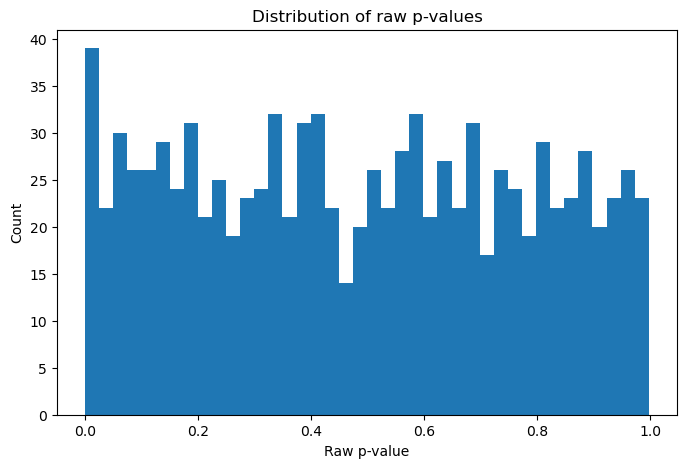

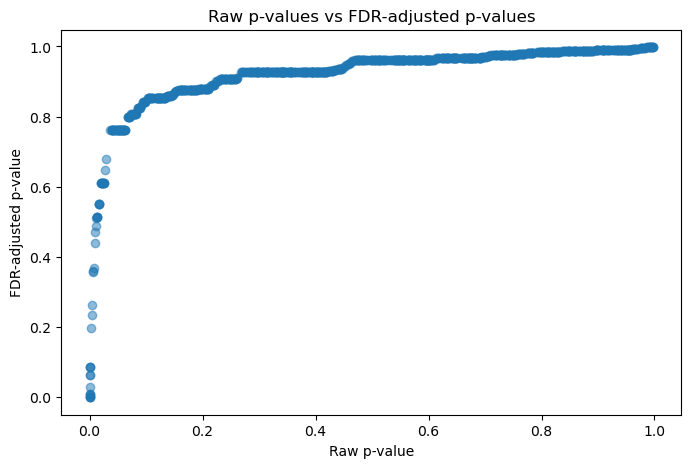

In [19]:

### 10. Visualizing raw and adjusted p-values

plt.figure(figsize=(8, 5))
plt.hist(pval_df["p_value"], bins=40)
plt.xlabel("Raw p-value")
plt.ylabel("Count")
plt.title("Distribution of raw p-values")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(pval_df["p_value"], pval_df["fdr_bh"], alpha=0.5)
plt.xlabel("Raw p-value")
plt.ylabel("FDR-adjusted p-value")
plt.title("Raw p-values vs FDR-adjusted p-values")
plt.show()

### 11. Permutation p-value

Permutation testing is useful when we do not want to rely strongly on distributional assumptions.

Let us test whether BMI is associated with y.


In [20]:
observed_corr = np.corrcoef(df["bmi"], df["y"])[0, 1]

n_perm = 5000
perm_corrs = []

for _ in range(n_perm):
    shuffled_y = np.random.permutation(df["y"])
    perm_corr = np.corrcoef(df["bmi"], shuffled_y)[0, 1]
    perm_corrs.append(perm_corr)

perm_corrs = np.array(perm_corrs)

perm_p = np.mean(np.abs(perm_corrs) >= abs(observed_corr))

observed_corr, perm_p

(0.4813321740204421, 0.0)

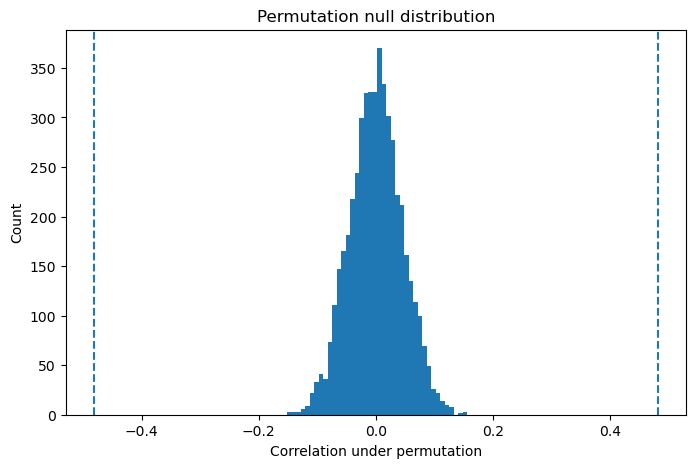

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(perm_corrs, bins=40)
plt.axvline(observed_corr, linestyle="--")
plt.axvline(-observed_corr, linestyle="--")
plt.xlabel("Correlation under permutation")
plt.ylabel("Count")
plt.title("Permutation null distribution")
plt.show()

The permutation p-value is empirical.

It asks:

> How often would I see a statistic this extreme if the outcome labels were randomly shuffled?

### 12. Bootstrap confidence interval

Bootstrap is usually more commonly used for confidence intervals than direct p-values.



In [22]:
n_boot = 2000
boot_bmi_estimates = []

for _ in range(n_boot):
    boot_sample = df.sample(n=len(df), replace=True)
    boot_model = smf.ols("y ~ age + bmi + smoking", data=boot_sample).fit()
    boot_bmi_estimates.append(boot_model.params["bmi"])

boot_bmi_estimates = np.array(boot_bmi_estimates)

ci_lower, ci_upper = np.percentile(boot_bmi_estimates, [2.5, 97.5])

ci_lower, ci_upper

(0.7273896136823674, 0.9485951320462989)

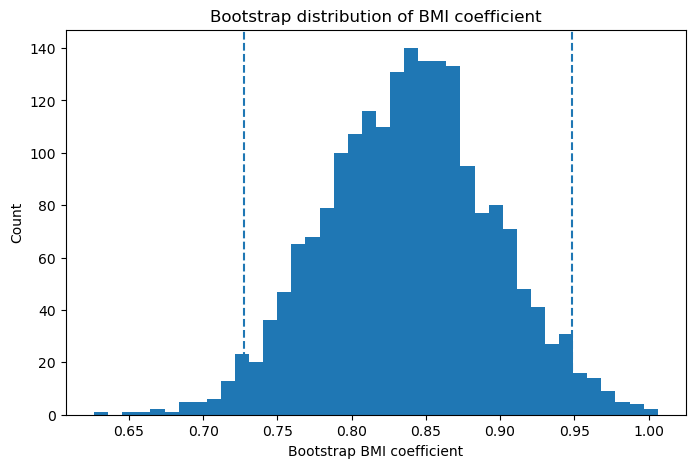

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(boot_bmi_estimates, bins=40)
plt.axvline(ci_lower, linestyle="--")
plt.axvline(ci_upper, linestyle="--")
plt.xlabel("Bootstrap BMI coefficient")
plt.ylabel("Count")
plt.title("Bootstrap distribution of BMI coefficient")
plt.show()

If the bootstrap confidence interval excludes zero, it supports evidence that the coefficient is not zero.


# Summary Table

| Type of p-value | Main question | Common model |
|---|---|---|
| Model p-value | Does the full model explain variation? | Linear regression |
| Predictor p-value | Does one predictor matter after adjustment? | Regression models |
| Wald p-value | Is estimate large relative to standard error? | GLM, Cox, logistic |
| Likelihood ratio p-value | Does a larger model fit better than a smaller model? | GLM, mixed models |
| Score test p-value | Would moving away from the null improve fit? | GWAS, mixed models |
| ANOVA p-value | Are group means different? | Experimental designs |
| Omnibus p-value | Does a group of parameters matter overall? | Categorical predictors |
| Adjusted p-value | Is result significant after multiple testing? | Genomics, high-dimensional data |
| Permutation p-value | Is result extreme under reshuffled labels? | Non-parametric testing |
| Bootstrap-based inference | Is effect stable under resampling? | Robust uncertainty estimation |


## Interpretation

When I look at a p-value now, I try not to treat it as a magical yes-or-no answer.

Instead, I ask:

1. What is the null hypothesis?
2. Is this a model-level or predictor-level p-value?
3. Is the test Wald, likelihood ratio, score, or permutation-based?
4. Is the p-value adjusted for multiple testing?
5. What is the effect size?
6. What is the confidence interval?
7. Does the result make scientific sense?

This habit makes statistical modeling much more meaningful.

## Summary

A p-value is not just a number in a regression table.

It is the result of a specific statistical test, attached to a specific null hypothesis, under specific assumptions.

The more carefully we understand those assumptions, the better we become at interpreting models.

For me, this was an important shift: moving from simply asking whether something is significant to asking what question the model is actually answering.

That is where statistical modeling starts to become real understanding.